# 03_prott5_features

In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"  # 使用国内镜像

from transformers import T5Tokenizer, T5EncoderModel
import torch

model_name = "Rostlab/prot_t5_base_mt_uniref50"  # base版本，不是xl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 直接从镜像站下载
tokenizer = T5Tokenizer.from_pretrained(model_name, do_lower_case=False)
model = T5EncoderModel.from_pretrained(model_name)

model = model.to(device)
model.eval()
print("ProtT5-base 加载成功！")

Device: cpu


Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: Rostlab/prot_t5_base_mt_uniref50
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ProtT5-base 加载成功！


In [ ]:
def preprocess_sequence(seq):
    seq = seq.upper()
    seq = " ".join(list(seq))
    return seq

In [5]:
import pandas as pd
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.cwd().parent.parent

train_df = pd.read_csv(PROJECT_ROOT / "data/processed/train.csv")
test_df = pd.read_csv(PROJECT_ROOT / "data/processed/test.csv")

print(train_df.shape, test_df.shape)

(3583, 2) (897, 2)


In [ ]:
# 提取embeding
import numpy as np
from tqdm import tqdm

def extract_prott5_embeddings(sequences, batch_size=8):
    embeddings = []

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i:i+batch_size]
        batch_seqs = [preprocess_sequence(seq) for seq in batch_seqs]

        tokens = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # shape: (batch, seq_len, hidden_dim)
        hidden_states = outputs.last_hidden_state

        # mean pooling（只算非padding）
        for j in range(hidden_states.size(0)):
            mask = attention_mask[j].unsqueeze(-1)
            emb = (hidden_states[j] * mask).sum(dim=0) / mask.sum()
            embeddings.append(emb.cpu().numpy())

    return np.array(embeddings)

In [ ]:
# 测试
sample_emb = extract_prott5_embeddings(
    train_df["sequence"].values[:10],
    batch_size=2
)

print(sample_emb.shape)

100%|██████████| 5/5 [00:01<00:00,  3.77it/s]

(10, 768)


In [ ]:
# 正式提取
X_train_prott5 = extract_prott5_embeddings(
    train_df["sequence"].values,
    batch_size=4
)

X_test_prott5 = extract_prott5_embeddings(
    test_df["sequence"].values,
    batch_size=4
)

# 保存文件
feature_dir = PROJECT_ROOT / "data" / "processed" / "prott5"
feature_dir.mkdir(parents=True, exist_ok=True)

np.save(feature_dir / "X_train_prott5.npy", X_train_prott5)
np.save(feature_dir / "X_test_prott5.npy", X_test_prott5)

y_train = train_df["label"].values
y_test = test_df["label"].values

np.save(feature_dir / "y_train.npy", y_train)
np.save(feature_dir / "y_test.npy", y_test)

print("ProtT5 features saved.")

100%|██████████| 225/225 [00:28<00:00,  8.00it/s]

ProtT5 features saved.


In [6]:
# 接入现有pipeline
X_train_prott5 = np.load(PROJECT_ROOT / "data" / "processed" / "prott5" / "X_train_prott5.npy")
X_test_prott5 = np.load(PROJECT_ROOT / "data" / "processed" / "prott5" / "X_test_prott5.npy")
y_train = np.load(PROJECT_ROOT / "data" / "processed" / "prott5" / "y_train.npy")
y_test = np.load(PROJECT_ROOT / "data" / "processed" / "prott5" / "y_test.npy")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_prott5)
X_test_scaled = scaler.transform(X_test_prott5)

print(X_train_scaled.shape, X_test_scaled.shape)

(3583, 768) (897, 768)


# prot-T5 modeling

## (1)LightGBM

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import make_scorer, confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "specificity": make_scorer(specificity_score)
}

def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
          
    } 
    return metrics


def print_metrics(metrics, title="Metrics"):
    print(f"===== {title} =====")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

In [8]:
# 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)


lgb_cv_results = cross_validate(
    lgb_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in lgb_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7298 ± 0.0148
test_precision: 0.6444 ± 0.0182
test_recall: 0.6491 ± 0.0296
test_f1: 0.6465 ± 0.0215
test_roc_auc: 0.7352 ± 0.0194
test_pr_auc: 0.6118 ± 0.0271
test_specificity: 0.7795 ± 0.0135


In [9]:
# 独立测试集评估
lgb_model.fit(X_train_scaled, y_train)

y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

lgb_metrics = evaluate_model(y_test, y_pred_lgb, y_prob_lgb)
print_metrics(lgb_metrics, title="prot-T5 + LightGBM Test")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb, digits=4))

[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14629
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## (2)SVM

In [10]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_cv_results = cross_validate(
    svm_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in svm_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7296 ± 0.0136
test_precision: 0.6434 ± 0.0171
test_recall: 0.6513 ± 0.0282
test_f1: 0.6471 ± 0.0197
test_roc_auc: 0.6976 ± 0.0179
test_pr_auc: 0.5175 ± 0.0290
test_specificity: 0.7777 ± 0.0141


In [11]:
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_metrics = evaluate_model(y_test, y_pred_svm, y_prob_svm)
print_metrics(svm_metrics, title="prot-T5 + SVM Test")

===== prot-T5 + SVM Test =====
ACC: 0.7168
Precision: 0.6229
Recall: 0.6520
Specificity: 0.7568
F1: 0.6371
MCC: 0.4055
ROC_AUC: 0.7100
PR_AUC: 0.5699


## (3)MLP

In [12]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_cv_results = cross_validate(
    mlp_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in mlp_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7195 ± 0.0150
test_precision: 0.6981 ± 0.0503
test_recall: 0.4886 ± 0.1243
test_f1: 0.5615 ± 0.0707
test_roc_auc: 0.7300 ± 0.0209
test_pr_auc: 0.6053 ± 0.0258
test_specificity: 0.8616 ± 0.0639


In [ ]:
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

mlp_metrics = evaluate_model(y_test, y_pred_mlp, y_prob_mlp)
print_metrics(mlp_metrics, title="MLP Test")

===== MLP Test =====
ACC: 0.7101
Precision: 0.6206
Recall: 0.6170
Specificity: 0.7676
F1: 0.6188
MCC: 0.3850
ROC_AUC: 0.7128
PR_AUC: 0.5592


## (4)XGBoost

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

xgb_cv_results = cross_validate(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in xgb_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7298 ± 0.0148
test_precision: 0.6444 ± 0.0182
test_recall: 0.6491 ± 0.0296
test_f1: 0.6465 ± 0.0215
test_roc_auc: 0.7360 ± 0.0195
test_pr_auc: 0.6121 ± 0.0276
test_specificity: 0.7795 ± 0.0135


In [15]:
# 独立测试集评估性能
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_metrics = evaluate_model(y_test, y_pred_xgb, y_prob_xgb)
print_metrics(xgb_metrics, title="XGBoost Test")

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:12] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBoost Test =====
ACC: 0.7168
Precision: 0.6229
Recall: 0.6520
Specificity: 0.7568
F1: 0.6371
MCC: 0.4055
ROC_AUC: 0.7200
PR_AUC: 0.5874


## (5)LR

In [16]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_cv_results = cross_validate(
    lr_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in lr_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7298 ± 0.0148
test_precision: 0.6444 ± 0.0182
test_recall: 0.6491 ± 0.0296
test_f1: 0.6465 ± 0.0215
test_roc_auc: 0.7353 ± 0.0194
test_pr_auc: 0.6099 ± 0.0301
test_specificity: 0.7795 ± 0.0135


In [17]:
# 独立测试集评估性能
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics = evaluate_model(y_test, y_pred_lr, y_prob_lr)
print_metrics(lr_metrics, title="Logistic Regression Test")

===== Logistic Regression Test =====
ACC: 0.7168
Precision: 0.6229
Recall: 0.6520
Specificity: 0.7568
F1: 0.6371
MCC: 0.4055
ROC_AUC: 0.7203
PR_AUC: 0.5885


## (6)RF

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_cv_results = cross_validate(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in rf_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")


test_accuracy: 0.7296 ± 0.0143
test_precision: 0.6441 ± 0.0179
test_recall: 0.6484 ± 0.0282
test_f1: 0.6460 ± 0.0206
test_roc_auc: 0.7358 ± 0.0193
test_pr_auc: 0.6122 ± 0.0262
test_specificity: 0.7795 ± 0.0135


In [19]:
# 独立测试集评估性能
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_metrics = evaluate_model(y_test, y_pred_rf, y_prob_rf)
print_metrics(rf_metrics, title="Random Forest Test")

===== Random Forest Test =====
ACC: 0.7168
Precision: 0.6229
Recall: 0.6520
Specificity: 0.7568
F1: 0.6371
MCC: 0.4055
ROC_AUC: 0.7199
PR_AUC: 0.5835


## (7)ET

In [20]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

et_cv_results = cross_validate(
    et_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in et_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")


test_accuracy: 0.7296 ± 0.0143
test_precision: 0.6441 ± 0.0179
test_recall: 0.6484 ± 0.0282
test_f1: 0.6460 ± 0.0206
test_roc_auc: 0.7357 ± 0.0195
test_pr_auc: 0.6118 ± 0.0265
test_specificity: 0.7795 ± 0.0135


In [21]:
# 独立测试集评估性能
et_model.fit(X_train_scaled, y_train)

y_pred_et = et_model.predict(X_test_scaled)
y_prob_et = et_model.predict_proba(X_test_scaled)[:, 1]

et_metrics = evaluate_model(y_test, y_pred_et, y_prob_et)
print_metrics(et_metrics, title="Extra Trees Test")

===== Extra Trees Test =====
ACC: 0.7168
Precision: 0.6229
Recall: 0.6520
Specificity: 0.7568
F1: 0.6371
MCC: 0.4055
ROC_AUC: 0.7203
PR_AUC: 0.5874


# prot-T5性能评估

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


All models predict exactly the same on test set.


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


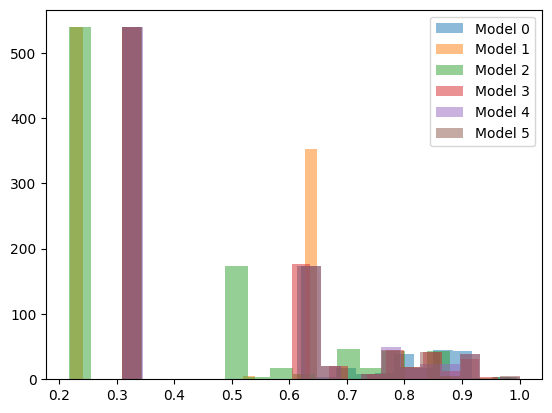

In [32]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


models = [lgb_model, svm_model, xgb_model, lr_model, rf_model, et_model]
preds = [model.predict(X_test_scaled) for model in models]

# 检查所有模型的预测是否完全相同
for i in range(len(preds[0])):
    if len(set(preds[j][i] for j in range(len(preds)))) > 1:
        print(f"Sample {i} predictions differ")
        break
else:
    print("All models predict exactly the same on test set.")


probs = [model.predict_proba(X_test_scaled)[:, 1] for model in models]
# 绘制每个模型概率的分布
for i, prob in enumerate(probs):
    plt.hist(prob, bins=20, alpha=0.5, label=f'Model {i}')
plt.legend()
plt.show()

In [26]:
results_df_esm2 = pd.DataFrame([
    {"Model": "prot-T5 + LightGBM", **lgb_metrics},
    {"Model": "prot-T5 + SVM", **svm_metrics},
    {"Model": "prot-T5 + MLP", **mlp_metrics},
    {"Model": "prot-T5 + XGBoost", **xgb_metrics},
    {"Model": "prot-T5 + Logistic Regression", **lr_metrics},
    {"Model": "prot-T5+ Random Forest", **rf_metrics},
    {"Model": "prot-T5 + Extra Trees", **et_metrics},
])

results_df_esm2

,Model,ACC,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC
0,prot-T5 + LightGBM,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.720186,0.584638
1,prot-T5 + SVM,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.709978,0.569860
2,prot-T5 + MLP,0.710145,0.620588,0.616959,0.767568,0.618768,0.384963,0.712797,0.559210
3,prot-T5 + XGBoost,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.720004,0.587398
4,prot-T5 + Logistic Regression,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.720252,0.588514
5,prot-T5+ Random Forest,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.719880,0.583479
6,prot-T5 + Extra Trees,0.716834,0.622905,0.652047,0.756757,0.637143,0.405451,0.720291,0.587389


In [23]:
result_dir = PROJECT_ROOT / "results" / "tables"
result_dir.mkdir(parents=True, exist_ok=True)

results_df_esm2.to_csv(result_dir / "prott5_model_results_with_torch_mlp.csv", index=False)
print("Saved.")

Saved.


In [24]:
def summarize_cv_results(cv_results, model_name):
    summary = {
        "Model": model_name,
        "ACC": np.mean(cv_results["test_accuracy"]),
        "Precision": np.mean(cv_results["test_precision"]),
        "Recall": np.mean(cv_results["test_recall"]),
        "Specificity":np.mean(cv_results["test_specificity"]),
        "F1": np.mean(cv_results["test_f1"]),
        "ROC_AUC": np.mean(cv_results["test_roc_auc"]),
        "PR_AUC": np.mean(cv_results["test_pr_auc"])
    }
    return summary

In [25]:
cv_summary_list = []

cv_summary_list.append(summarize_cv_results(lgb_cv_results, "LightGBM"))
cv_summary_list.append(summarize_cv_results(svm_cv_results, "SVM"))
cv_summary_list.append(summarize_cv_results(xgb_cv_results, "XGBoost"))
cv_summary_list.append(summarize_cv_results(mlp_cv_results, "MLP"))
cv_summary_list.append(summarize_cv_results(lr_cv_results, "LogReg"))
cv_summary_list.append(summarize_cv_results(rf_cv_results, "RandomForest"))
cv_summary_list.append(summarize_cv_results(et_cv_results, "ExtraTrees"))

cv_df = pd.DataFrame(cv_summary_list)
cv_df

,Model,ACC,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,LightGBM,0.729836,0.644369,0.649084,0.779543,0.646518,0.735242,0.611791
1,SVM,0.729557,0.643356,0.651282,0.777740,0.647071,0.697613,0.517537
2,XGBoost,0.729836,0.644369,0.649084,0.779543,0.646518,0.735984,0.612147
3,MLP,0.719509,0.698144,0.488645,0.861585,0.561506,0.730009,0.605257
4,LogReg,0.729836,0.644369,0.649084,0.779543,0.646518,0.735261,0.609862
5,RandomForest,0.729558,0.644137,0.648352,0.779543,0.646050,0.735805,0.612231
6,ExtraTrees,0.729558,0.644137,0.648352,0.779543,0.646050,0.735660,0.611789
